In [2]:
import pandas as pd

coral = pd.read_csv('../data/raw/archive 2/coral.csv')
coral_whole = pd.read_csv('../data/raw/archive 2/coral_whole.csv')

print("coral.csv shape:", coral.shape)
print("coral_whole.csv shape:", coral_whole.shape)

C:\Users\Asthi\AppData\Local\Temp\ipykernel_25816\2218451916.py:3: DtypeWarning: Columns (0: Distance_to_Shore, 1: Turbidity, 2: Percent_Bleaching) have mixed types. Specify dtype option on import or set low_memory=False.
  coral = pd.read_csv('../data/raw/archive 2/coral.csv')


coral.csv shape: (41361, 62)
coral_whole.csv shape: (41361, 18)


In [3]:
key_cols = ['Percent_Bleaching', 'Bleaching_Level', 'Temperature_Mean', 
            'SSTA', 'TSA', 'Turbidity', 'Depth_m', 'Distance_to_Shore',
            'Latitude_Degrees', 'Longitude_Degrees', 'Date_Year']

print(coral[key_cols].isnull().sum())
print()
print("Total rows:", len(coral))

Percent_Bleaching    0
Bleaching_Level      0
Temperature_Mean     0
SSTA                 0
TSA                  0
Turbidity            0
Depth_m              0
Distance_to_Shore    0
Latitude_Degrees     0
Longitude_Degrees    0
Date_Year            0
dtype: int64

Total rows: 41361


In [4]:
coral['Percent_Bleaching'] = pd.to_numeric(coral['Percent_Bleaching'], errors='coerce')
coral_clean = coral.dropna(subset=['Percent_Bleaching']).copy()

print("Original rows:", len(coral))
print("Rows after dropping missing Percent_Bleaching:", len(coral_clean))
print()
print(coral_clean['Percent_Bleaching'].describe())

Original rows: 41361
Rows after dropping missing Percent_Bleaching: 34515

count    34515.000000
mean         9.619465
std         20.190956
min          0.000000
25%          0.000000
50%          0.250000
75%          6.000000
max        100.000000
Name: Percent_Bleaching, dtype: float64


In [5]:
def bleaching_category(pct):
    if pct == 0:
        return 'None'
    elif pct <= 10:
        return 'Low'
    elif pct <= 50:
        return 'Moderate'
    else:
        return 'Severe'

coral_clean['Bleaching_Category'] = coral_clean['Percent_Bleaching'].apply(bleaching_category)

print(coral_clean['Bleaching_Category'].value_counts())
print()
print(coral_clean['Bleaching_Category'].value_counts(normalize=True) * 100)

Bleaching_Category
None        16629
Low         10950
Moderate     4571
Severe       2365
Name: count, dtype: int64

Bleaching_Category
None        48.179053
Low         31.725337
Moderate    13.243517
Severe       6.852093
Name: proportion, dtype: float64


In [6]:
# Convert to numeric, coercing bad values to NaN
for col in ['Distance_to_Shore', 'Turbidity']:
    coral_clean[col] = pd.to_numeric(coral_clean[col], errors='coerce')

# Check how many nulls this created
print(coral_clean[['Distance_to_Shore', 'Turbidity']].isnull().sum())

# Drop those few bad rows (negligible amount)
coral_clean = coral_clean.dropna(subset=['Distance_to_Shore', 'Turbidity'])
print()
print("Rows remaining after cleanup:", len(coral_clean))

Distance_to_Shore    2
Turbidity            6
dtype: int64

Rows remaining after cleanup: 34507


In [7]:
print(coral_clean[key_cols].dtypes)

Percent_Bleaching    float64
Bleaching_Level          str
Temperature_Mean         str
SSTA                     str
TSA                      str
Turbidity            float64
Depth_m                  str
Distance_to_Shore    float64
Latitude_Degrees     float64
Longitude_Degrees    float64
Date_Year              int64
dtype: object


In [8]:
# Check for non-numeric values in these columns
cols_to_fix = ['Temperature_Mean', 'SSTA', 'TSA', 'Depth_m']

for col in cols_to_fix:
    non_numeric = pd.to_numeric(coral_clean[col], errors='coerce').isna().sum()
    print(f"{col}: {non_numeric} non-numeric values")

Temperature_Mean: 100 non-numeric values
SSTA: 116 non-numeric values
TSA: 116 non-numeric values
Depth_m: 1680 non-numeric values


In [9]:
for col in cols_to_fix:
    bad_mask = pd.to_numeric(coral_clean[col], errors='coerce').isna()
    print(f"--- {col} ---")
    print(coral_clean.loc[bad_mask, col].value_counts().head(5))
    print()

--- Temperature_Mean ---
Temperature_Mean
nd    100
Name: count, dtype: int64

--- SSTA ---
SSTA
nd    116
Name: count, dtype: int64

--- TSA ---
TSA
nd    116
Name: count, dtype: int64

--- Depth_m ---
Depth_m
nd    1680
Name: count, dtype: int64



In [10]:
# Convert all four columns to numeric, turning "nd" into NaN
for col in cols_to_fix:
    coral_clean[col] = pd.to_numeric(coral_clean[col], errors='coerce')

# Drop rows with missing values in any of these columns
coral_clean = coral_clean.dropna(subset=cols_to_fix)

print("Rows remaining after full cleanup:", len(coral_clean))
print()
print(coral_clean[key_cols].dtypes)

Rows remaining after full cleanup: 32714

Percent_Bleaching    float64
Bleaching_Level          str
Temperature_Mean     float64
SSTA                 float64
TSA                  float64
Turbidity            float64
Depth_m              float64
Distance_to_Shore    float64
Latitude_Degrees     float64
Longitude_Degrees    float64
Date_Year              int64
dtype: object


In [11]:
categorical_cols = ['Ocean_Name', 'Country_Name', 'Exposure', 'Realm_Name']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(coral_clean[col].value_counts().head(10))
    print(f"Unique values: {coral_clean[col].nunique()}")
    print()

--- Ocean_Name ---
Ocean_Name
Pacific         16267
Atlantic        13087
Indian           1982
Red Sea          1037
Arabian Gulf      341
Name: count, dtype: int64
Unique values: 5

--- Country_Name ---
Country_Name
Malaysia            4228
United States       4127
Mexico              2045
Australia           1822
Philippines         1708
Indonesia           1706
French Polynesia    1348
Jamaica             1073
Fiji                1011
Japan                962
Name: count, dtype: int64
Unique values: 82

--- Exposure ---
Exposure
Sheltered    18243
Exposed      11794
Sometimes     2677
Name: count, dtype: int64
Unique values: 3

--- Realm_Name ---
Realm_Name
Central Indo-Pacific           13793
Tropical Atlantic              13076
Western Indo-Pacific            3140
Eastern Indo-Pacific            1618
Temperate Australasia            532
Temperate Northern Pacific       494
Tropical Eastern Pacific          50
Temperate Northern Atlantic       11
Name: count, dtype: int64
Unique v

In [12]:
# Simplify Country_Name: keep top 15, group rest as "Other"
top_countries = coral_clean['Country_Name'].value_counts().head(15).index
coral_clean['Country_Simplified'] = coral_clean['Country_Name'].apply(
    lambda x: x if x in top_countries else 'Other'
)

print(coral_clean['Country_Simplified'].value_counts())

Country_Simplified
Other               8937
Malaysia            4228
United States       4127
Mexico              2045
Australia           1822
Philippines         1708
Indonesia           1706
French Polynesia    1348
Jamaica             1073
Fiji                1011
Japan                962
Egypt                927
Cuba                 767
Belize               739
Bahamas              659
China                655
Name: count, dtype: int64


In [13]:
# One-hot encode all categorical columns
categorical_to_encode = ['Ocean_Name', 'Exposure', 'Realm_Name', 'Country_Simplified']

coral_encoded = pd.get_dummies(coral_clean, columns=categorical_to_encode, drop_first=False)

print("Shape before encoding:", coral_clean.shape)
print("Shape after encoding:", coral_encoded.shape)
print()
print(coral_encoded.columns.tolist())

Shape before encoding: (32714, 64)
Shape after encoding: (32714, 92)

['Site_ID', 'Sample_ID', 'Data_Source', 'Latitude_Degrees', 'Longitude_Degrees', 'Reef_ID', 'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name', 'City_Town_Name', 'Site_Name', 'Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year', 'Depth_m', 'Substrate_Name', 'Percent_Cover', 'Bleaching_Level', 'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_Frequ

In [14]:
# Columns to exclude (IDs, text, redundant, or target-related)
exclude_cols = [
    'Site_ID', 'Sample_ID', 'Data_Source', 'Reef_ID', 'Ecoregion_Name',
    'Country_Name', 'State_Island_Province_Name', 'City_Town_Name', 'Site_Name',
    'Substrate_Name', 'Bleaching_Level', 'Date', 'Site_Comments', 
    'Sample_Comments', 'Bleaching_Comments',
    'Percent_Bleaching', 'Bleaching_Category'  # targets, not features
]

feature_cols = [col for col in coral_encoded.columns if col not in exclude_cols]

print("Number of features:", len(feature_cols))
print()
print(feature_cols)

Number of features: 75

['Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year', 'Depth_m', 'Percent_Cover', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'Ocean_Name_Arabian Gulf', 'Ocean_Name_Atlantic', 'Ocean_Name_Indian', 'Ocean_Name_Pacific', 'Ocean_Name_Red Sea', 'Exposure_Exposed', 'Exposure_Sheltered', 'Exposure_S

In [15]:
X = coral_encoded[feature_cols]

missing_summary = X.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:")
print(missing_summary)
print()
print("Total missing values across all features:", X.isnull().sum().sum())


Columns with missing values:
Series([], dtype: int64)

Total missing values across all features: 0


In [16]:
# Features
X = coral_encoded[feature_cols]

# Two possible targets
y_regression = coral_encoded['Percent_Bleaching']       # for regression approach
y_classification = coral_encoded['Bleaching_Category']  # for classification approach

print("X shape:", X.shape)
print("y_regression shape:", y_regression.shape)
print("y_classification shape:", y_classification.shape)
print()
print(y_classification.value_counts())

X shape: (32714, 75)
y_regression shape: (32714,)
y_classification shape: (32714,)

Bleaching_Category
None        16537
Low         10394
Moderate     4105
Severe       1678
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

# We'll focus on classification (Bleaching_Category) as our primary target
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_classification, test_size=0.3, random_state=42, stratify=y_classification
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print()
print("Train class distribution:")
print(y_train.value_counts(normalize=True) * 100)

Train shape: (22899, 75)
Validation shape: (4907, 75)
Test shape: (4908, 75)

Train class distribution:
Bleaching_Category
None        50.548059
Low         31.774313
Moderate    12.546399
Severe       5.131228
Name: proportion, dtype: float64


C:\Users\Asthi\AppData\Local\Temp\ipykernel_25816\2238328282.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=coral_clean, x='Bleaching_Category', order=['None', 'Low', 'Moderate', 'Severe'], palette='YlOrRd')


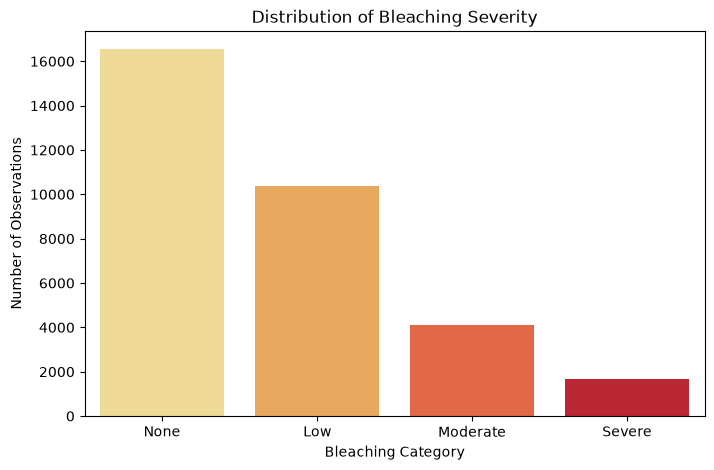

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bleaching category distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=coral_clean, x='Bleaching_Category', order=['None', 'Low', 'Moderate', 'Severe'], palette='YlOrRd')
plt.title('Distribution of Bleaching Severity')
plt.xlabel('Bleaching Category')
plt.ylabel('Number of Observations')
plt.show()

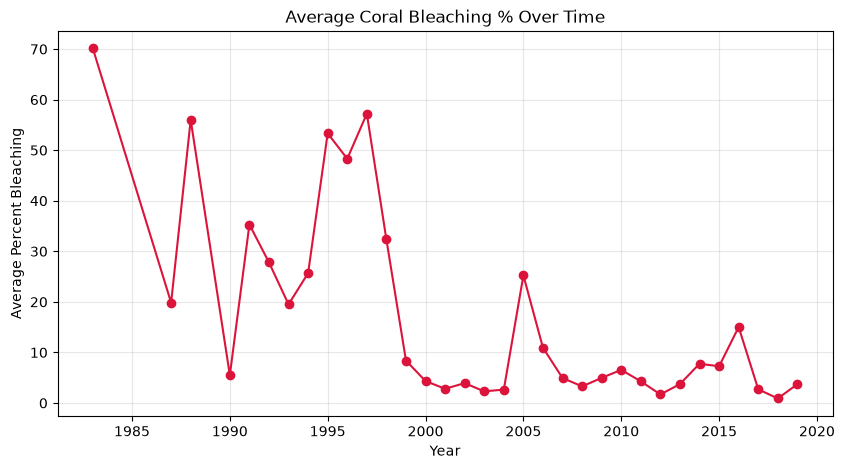

In [19]:
plt.figure(figsize=(10, 5))
yearly_avg = coral_clean.groupby('Date_Year')['Percent_Bleaching'].mean()
yearly_avg.plot(kind='line', marker='o', color='crimson')
plt.title('Average Coral Bleaching % Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleaching')
plt.grid(True, alpha=0.3)
plt.show()

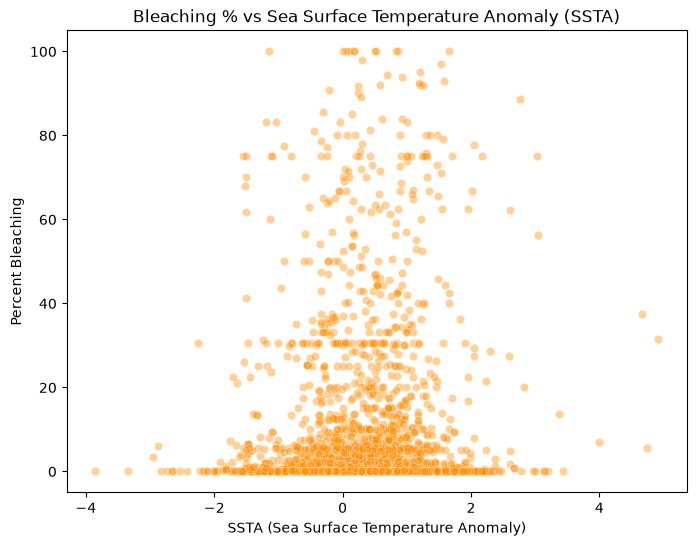

In [20]:
plt.figure(figsize=(8, 6))
sample = coral_clean.sample(min(3000, len(coral_clean)), random_state=42)  # sample for readability
sns.scatterplot(data=sample, x='SSTA', y='Percent_Bleaching', alpha=0.4, color='darkorange')
plt.title('Bleaching % vs Sea Surface Temperature Anomaly (SSTA)')
plt.xlabel('SSTA (Sea Surface Temperature Anomaly)')
plt.ylabel('Percent Bleaching')
plt.show()